# **Questão** 1 - EDA


Cenário

Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”
Sua missão é realizar uma análise exploratória inicial do dataset vendas_2023_2024.csv e responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

Premissas obrigatórias

    Utilize apenas o dataset vendas_2023_2024.csv
    **Não faça limpeza nem tratamento dos dados**
    **Apenas observe, agregue e descreva**


Tarefas:
Parte 1 — Visão geral do dataset
Informe:

    Quantidade total de linhas
    Quantidade total de colunas
    Intervalo de datas analisado (data mínima e máxima)

Parte 2 — Análise de valores numéricos
Para a coluna "total", calcule:

    Valor mínimo
    Valor máximo
    Valor médio

In [ ]:
import pandas as pd

# Carrega o arquivo
df = pd.read_csv('vendas_2023_2024.csv')

# --- PARTE 1 ---
linhas, colunas = df.shape
print("--- PARTE 1 ---")
print(f"Quantidade total de linhas: {linhas}")
print(f"Quantidade total de colunas: {colunas}")

# O Pandas converte pra gente apenas observar as pontas (sem alterar a base)
datas = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True)
print(f"Data mínima: {datas.min().date()}")
print(f"Data máxima: {datas.max().date()}")

# --- PARTE 2 ---
print("\n--- PARTE 2 ---")
print(f"Valor mínimo de total: R$ {df['total'].min():.2f}")
print(f"Valor máximo de total: R$ {df['total'].max():.2f}")
print(f"Valor médio de total: R$ {df['total'].mean():.2f}")

--- PARTE 1 ---
Quantidade total de linhas: 9895
Quantidade total de colunas: 6
Data mínima: 2023-01-01
Data máxima: 2024-12-31

--- PARTE 2 ---
Valor mínimo de total: R$ 294.50
Valor máximo de total: R$ 2222973.00
Valor médio de total: R$ 263797.83


```
-- Questão 1: EDA
-- Dialeto: PostgreSQL
-- Base: vendas_2023_2024.csv
-- Executado no Supabase


SELECT
    -- Conta o total de vendas focando na chave primária
    COUNT(id) AS total_linhas,
    
    -- Busca o número de colunas direto no dicionário do banco
    (SELECT COUNT(column_name)
     FROM information_schema.columns
     WHERE table_name = 'vendas_2023_2024') AS total_colunas,
    
    -- Pega a "primeira" e "última" data (em ordem alfabética)
    MIN(sale_date) AS data_min_bruta,
    MAX(sale_date) AS data_max_bruta,
    
    -- Acha o menor e o maior valor faturado
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    
    -- Converte a média para número decimal (::numeric) e arredonda
    ROUND(AVG(total)::numeric, 2) AS valor_medio
    
FROM vendas_2023_2024
```

# Questão 2 - Produtos

Cenário

Gabriel percebeu que seus dados estão desorganizados e sem um padrão definido e isso pode tornar o trabalho de análise mais trabalhoso. Precisamos melhorar isso utilizando o Python.
Sua missão é realizar uma normalização dos dados presentes no arquivo produtos_raw.csv.


Premissas obrigatórias

    Utilize apenas o CSV produtos_raw.csv
    Utilize obrigatoriamente Python 3


Tarefas:

Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.

Parte 2 — Converta os valores para o tipo numérico.

Parte 3 — Remova as duplicatas.

In [ ]:
import pandas as pd

# Carregando a base bruta
df_produtos = pd.read_csv('produtos_raw.csv')

# ==========================================
# PARTE 1: Padronização das Categorias
# ==========================================
# Função defensiva: remove espaços, coloca em minúsculo e busca o radical da palavra
def padronizar_categoria(texto):
    texto_limpo = str(texto).lower().replace(' ', '')

    if 'ele' in texto_limpo or 'let' in texto_limpo:
        return 'eletrônicos'
    elif 'prop' in texto_limpo or 'pul' in texto_limpo:
        return 'propulsão'
    elif 'anc' in texto_limpo or 'enc' in texto_limpo:
        return 'ancoragem'

    return texto_limpo # Fallback de segurança

# Aplicando a regra na coluna
df_produtos['actual_category'] = df_produtos['actual_category'].apply(padronizar_categoria)


# ==========================================
# PARTE 2: Conversão para Numérico
# ==========================================
# Removemos a string 'R$', tiramos os espaços em branco (strip) e convertemos para float
df_produtos['price'] = (
    df_produtos['price']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.strip()
    .astype(float)
)


# ==========================================
# PARTE 3: Remoção de Duplicatas e Contagem
# ==========================================
# Guardamos o tamanho original da base antes de apagar qualquer coisa
total_antes = len(df_produtos)

# Aplicamos a guilhotina focando apenas no código do produto
df_produtos = df_produtos.drop_duplicates(subset=['code'], keep='first')

# Guardamos o novo tamanho da base limpa
total_depois = len(df_produtos)

# A matemática básica pra saber quantas cabeças rolaram
duplicadas_removidas = total_antes - total_depois

# Exibindo o resultado final com a resposta da plataforma
print("--- Catálogo Limpo ---")
print(df_produtos)
print(f"\nTotal de categorias únicas: {df_produtos['actual_category'].unique()}")
print(f"Total de produtos após limpeza: {total_depois}")
print(f"-> PRODUTOS DUPLICADOS REMOVIDOS: {duplicadas_removidas}")

--- Catálogo Limpo ---
                                          name     price  code actual_category
0                  Transponder AIS Maré Magnum  33122.52     1     eletrônicos
1                    Transponder Furuno Marlin  13998.15     2     eletrônicos
2                 Radar Furuno Pulse Leviathan   9024.19     3     eletrônicos
3                    Rádio AIS Hydro Tidal Zen   3381.88     4     eletrônicos
4               Piloto Automático Furuno Storm  23669.01     5     eletrônicos
..                                         ...       ...   ...             ...
152                     Corrente Delta Vox Ion    495.98   146       ancoragem
153  Corrente Danforth Force Leviathan Impulse   3030.08   147       ancoragem
154          Âncora Delta Force Barracuda Mako   4785.56   148       ancoragem
155                   Cabo de Nylon Bruce Core   1163.62   149       ancoragem
156          Cabo de Nylon Danforth Magnum Vox   1645.66   150       ancoragem

[150 rows x 4 columns]

Tota

# Questão 3 - Custos de Importação

Cenário
Além dos dados de produtos, Gabriel percebeu também que o arquivo custos_importacao.json tem todos os dados históricos dos preços de compra aninhados num único campo. Para facilitar a análise dessa informação no banco de dados é necessário melhorarmos isso.
Premissas obrigatórias
Utilize apenas o JSON custos_importacao.json
Utilize obrigatoriamente Python 3

Tarefa:
- Carregue o arquivo JSON e gere um novo arquivo CSV organizando-o de acordo com a definição na imagem abaixo.


In [ ]:
import pandas as pd
import json

# 1. Carrega o JSON original
with open('custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_brutos = json.load(f)

# 2. Cria uma lista vazia para guardar as linhas achatadas
linhas_limpas = []

# 3. O famoso "For dentro de For" para explodir os dados
for produto in dados_brutos:
    # Para cada produto, vamos iterar o histórico de preços dele
    for historico in produto['historic_data']:

        # Montamos a linha já misturando os dados do produto com os do histórico
        linha = {
            'product_id': produto['product_id'],
            'product_name': produto['product_name'],
            'category': produto['category'],
            'start_date': historico['start_date'],
            'usd_price': historico['usd_price']
        }

        # Adicionamos essa linha na nossa lista final
        linhas_limpas.append(linha)

# 4. Transforma a lista de dicionários em uma tabela do Pandas
df_achatado = pd.DataFrame(linhas_limpas)

# 5. Salva como CSV
nome_arquivo_saida = 'custos_importacao_achatado.csv'
df_achatado.to_csv(nome_arquivo_saida, index=False, encoding='utf-8')

print("--- Prévia do novo CSV ---")
print(df_achatado)

FileNotFoundError: [Errno 2] No such file or directory: 'custos_importacao.json'

# Questão 4 - Dados Públicos

Cenário

O Sr. Almir identificou que alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.
O problema é que:

    O sistema de vendas (vendas_2023_2024.csv) registra valores em real BRL
    O catálogo de fornecedores (custos_importacao.json) registra custos unitários em dollar USD
    O câmbio varia diariamente

Até hoje, ninguém cruzou o custo em dólar do dia da venda com o valor de venda em reais.
Sua missão é abrir essa “caixa preta” financeira e identificar onde houve prejuízo real.

Premissas obrigatórias:

    O custo em USD é unitário
    O custo em BRL deve ser calculado usando o câmbio da data da venda
    A taxa de câmbio deve ser considerada a média da cotação de venda do dia (Banco Central)
    A receita total do produto considera todas as vendas (inclusive as sem prejuízo)
    Ignore impostos e frete


Tarefas:
Parte 1 — Cálculo e modelagem

    Calcule o custo total em BRL por transação
    Identifique transações com prejuízo
    Agregue os dados por id_produto, gerando:

    Receita total (BRL)
    Prejuízo total (BRL)
    Percentual de perda (prejuízo_total / receita_total)

Parte 2 — Análise visual
Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. (Inserir o gráfico no relatório/dashboard final)
Parte 3 —  Explique sobre o desenvolvimento :

    Qual data de câmbio você utilizou?
    Como definiu o prejuízo?
    Alguma suposição relevante?




Antes de aplicar qualquer conversão nas datas de venda, é fundamental entender a anomalia estrutural da coluna sale_date em vez de apenas forçar uma solução. Identificamos visualmente que existem formatos misturados convivendo na mesma coluna.

A nossa hipótese: Os dados variam exclusivamente entre o padrão de banco de dados (YYYY-MM-DD) e o padrão regional brasileiro (DD-MM-YYYY).

Para garantir que não seremos corrompidos por formatos americanos (MM-DD-YYYY) ocultos na base, aplicaremos uma prova matemática: como ambos os formatos propostos utilizam o mês na posição central da string, isolaremos esse valor em todas as linhas. Se o valor máximo encontrado no meio da data for menor ou igual a 12, nossa hipótese estará 100% comprovada e poderemos seguir com a conversão segura utilizando a premissa de dayfirst=True.


In [ ]:
import pandas as pd

# 1. Carrega as vendas
vendas = pd.read_csv('vendas_2023_2024.csv')

# 2. Vamos criar uma função que pega a data em texto, divide no hífen ou barra, e pega o elemento do meio [1]
def extrai_meio_da_data(data_texto):
    texto = str(data_texto)
    pedacos = texto.split('-')

    # Se a data estiver completa (3 pedaços: dia, mes, ano)
    if len(pedacos) == 3:
        return int(pedacos[1]) # O índice [1] é o pedaço do meio
    return 0

# 3. Aplica a função e pega o maior número que apareceu no meio
vendas['valor_do_meio'] = vendas['sale_date'].apply(extrai_meio_da_data)
maior_valor_no_meio = vendas['valor_do_meio'].max()

print(f"O MAIOR valor encontrado no meio das datas foi: {maior_valor_no_meio}")

if maior_valor_no_meio <= 12:
    print("CONCLUSÃO: teoria está 100% CORRETA! O meio é sempre o mês.")
    print("Podemos assumir tranquilamente que os únicos formatos são YYYY-MM-DD ou DD-MM-YYYY.")
else:
    print("ALERTA: Tem número maior que 12 no meio! Provavelmente existe o padrão MM-DD-YYYY escondido.")

O MAIOR valor encontrado no meio das datas foi: 12
CONCLUSÃO: teoria está 100% CORRETA! O meio é sempre o mês.
Podemos assumir tranquilamente que os únicos formatos são YYYY-MM-DD ou DD-MM-YYYY.


In [ ]:
# ==========================================
# PASSO 1: CARREGAMENTO E ORDENAÇÃO DE DATAS
# ==========================================
import pandas as pd

# 1. Tabela de Vendas (Base bruta do desafio)
vendas = pd.read_csv('vendas_2023_2024.csv')

# Aplicando a conversão com a premissa que validamos matematicamente (dayfirst=True)
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)

# ORDENAÇÃO CRONOLÓGICA: Do passado para o futuro
vendas = vendas.sort_values('sale_date')


# 2. Tabela de Custos (SINALIZADOR: Aqui usamos o CSV que geramos na Questão 3)
custos = pd.read_csv('custos_importacao_achatado.csv')

# A data aqui é mais fácil porque geramos o arquivo achatado
custos['start_date'] = pd.to_datetime(custos['start_date'], format='%d/%m/%Y')

# ORDENAÇÃO CRONOLÓGICA dos custos
custos = custos.sort_values('start_date')

print("--- Passo 1 Executado ---")
print("Bases carregadas, datas padronizadas e cronologia ordenada com sucesso!")

# ==========================================
# PASSO 2: CONSUMO DA API DO BANCO CENTRAL
# ==========================================
import requests
from datetime import timedelta

print("Buscando cotações históricas na API do Banco Central...")

data_inicial_calculada = vendas['sale_date'].min() - timedelta(days=7)

# O BCB exige o formato MM-DD-YYYY na URL, então usamos o strftime para formatar
# Pegamos a menor data de venda e tiramos 7 dias de margem de segurança
data_inicial = data_inicial_calculada.strftime('%m-%d-%Y')
data_final = vendas['sale_date'].max().strftime('%m-%d-%Y')

# Montando a URL da API pública Olinda do BCB
url_bcb = f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='{data_inicial}'&@dataFinalCotacao='{data_final}'&$top=10000&$format=json"

# Fazendo a requisição e tratando indisponibilidade da API
response = requests.get(url_bcb)

if response.status_code != 200:
    # BCB fora do ar: busca no Yahoo Finance como fallback
    print(f"API do BCB indisponível (status {response.status_code}). Buscando no Yahoo Finance...")

    data_inicio_yf = data_inicial_calculada.strftime('%Y-%m-%d')
    data_fim_yf = vendas['sale_date'].max().strftime('%Y-%m-%d')

    url_yf = f"https://query1.finance.yahoo.com/v8/finance/chart/USDBRL=X?interval=1d&period1={int(pd.Timestamp(data_inicio_yf).timestamp())}&period2={int(pd.Timestamp(data_fim_yf).timestamp())}"

    resp_yf = requests.get(url_yf, headers={'User-Agent': 'Mozilla/5.0'})
    dados_yf = resp_yf.json()['chart']['result'][0]

    datas = pd.to_datetime(dados_yf['timestamp'], unit='s').normalize()
    precos = dados_yf['indicators']['quote'][0]['close']

    cotacoes = pd.DataFrame({'data': datas, 'cotacao_venda': precos}).dropna()
else:
    # API respondeu: processa o JSON normalmente
    dados_bcb = response.json()['value']

    # Transformando o JSON do BCB numa tabela do Pandas
    cotacoes = pd.DataFrame(dados_bcb)

    # O BCB manda data e hora juntos, o '.dt.normalize()' arranca a hora e deixa só a data limpa
    cotacoes['data'] = pd.to_datetime(cotacoes['dataHoraCotacao']).dt.normalize()

    # Pegamos só as colunas que importam e renomeamos
    cotacoes = cotacoes[['data', 'cotacaoVenda']].rename(columns={'cotacaoVenda': 'cotacao_venda'})

# Ordenação cronológica da tabela de cotações (fundamental pro Passo 3)
cotacoes = cotacoes.sort_values('data')

print("--- Passo 2 Executado ---")
print(f"Cotações do dólar baixadas com sucesso! Total de dias úteis com cotação: {len(cotacoes)}")
print(cotacoes.head())

# ==========================================
# PASSO 3: OS CRUZAMENTOS TEMPORAIS (MERGE_ASOF)
# ==========================================
print("Iniciando o cruzamento temporal de dados...")

# CRUZAMENTO A: Vendas + Cotação do Dólar (BCB)
vendas_cotadas = pd.merge_asof(
    vendas,
    cotacoes,
    left_on='sale_date',
    right_on='data',
    direction='backward'
)

# Antes de fazer o segundo merge_asof... (continua o código normal)
vendas_cotadas = vendas_cotadas.sort_values('sale_date')

# Antes de fazer o segundo merge_asof, o Pandas exige que a base continue ordenada
vendas_cotadas = vendas_cotadas.sort_values('sale_date')

# CRUZAMENTO B: Vendas (já com dólar) + Custos de Importação
# Pega o custo vigente na data da venda, desde que seja o mesmo produto (by_...)
vendas_enriquecidas = pd.merge_asof(
    vendas_cotadas,
    custos,
    left_on='sale_date',
    right_on='start_date',
    left_by='id_product',
    right_by='product_id',
    direction='backward'
)

print("--- Passo 3 Executado ---")
print("Bases cruzadas com sucesso! Não perdemos nenhuma venda no buraco negro do fim de semana.")
# Mostrando só as colunas que importam para ver se deu match
print(vendas_enriquecidas[['sale_date', 'id_product', 'total', 'cotacao_venda', 'usd_price']].head())

# ==========================================
# PASSO 4: CÁLCULO FINANCEIRO E AGREGAÇÃO (VIA SQL)
# ==========================================
import sqlite3

print("Criando banco de dados em memória e rodando a regra de negócio em SQL...")

# 1. Cria uma conexão com um banco de dados SQL virtual (na memória RAM)
conn = sqlite3.connect(':memory:')

# 2. Joga a nossa tabela enriquecida lá pra dentro com o nome 'vendas_tb'
vendas_enriquecidas.to_sql('vendas_tb', conn, index=False)

# 3. A QUERY (Usando CTEs para ficar organizado e legível)
query = """
WITH CalculoLinha AS (
    SELECT
        id_product,
        product_name,
        total AS receita_linha,
        (usd_price * cotacao_venda * qtd) AS custo_linha
    FROM vendas_tb
),
PrejuizoLinha AS (
    SELECT
        id_product,
        product_name,
        receita_linha,
        -- Regra: Só é prejuízo se o custo for maior que a receita
        CASE
            WHEN custo_linha > receita_linha THEN (custo_linha - receita_linha)
            ELSE 0
        END AS prejuizo_linha
    FROM CalculoLinha
)
SELECT
    id_product,
    product_name,
    SUM(receita_linha) AS receita_total_brl,
    SUM(prejuizo_linha) AS prejuizo_total_brl,
    (SUM(prejuizo_linha) / SUM(receita_linha)) AS percentual_perda
FROM PrejuizoLinha
GROUP BY
    id_product,
    product_name
HAVING
    SUM(prejuizo_linha) > 0 -- Traz apenas quem sangrou dinheiro
ORDER BY
    prejuizo_total_brl DESC;
"""

# 4. O Pandas roda a query lá no banco virtual e já nos devolve o resultado formatado
produtos_com_prejuizo = pd.read_sql_query(query, conn)

print("--- Passo 4 (Versão SQL) Executado ---")
print("Caixa preta financeira aberta! Estes são os maiores ralos de dinheiro:")
print(produtos_com_prejuizo.head(10))



--- Passo 1 Executado ---
Bases carregadas, datas padronizadas e cronologia ordenada com sucesso!
Buscando cotações históricas na API do Banco Central...
API do BCB indisponível (status 503). Buscando no Yahoo Finance...
--- Passo 2 Executado ---
Cotações do dólar baixadas com sucesso! Total de dias úteis com cotação: 527
        data  cotacao_venda
0 2022-12-26         5.1643
1 2022-12-27         5.2175
2 2022-12-28         5.2923
3 2022-12-29         5.2668
4 2022-12-30         5.2846
Iniciando o cruzamento temporal de dados...
--- Passo 3 Executado ---
Bases cruzadas com sucesso! Não perdemos nenhuma venda no buraco negro do fim de semana.
   sale_date  id_product      total  cotacao_venda  usd_price
0 2023-01-01          91  512566.80         5.2846   26303.31
1 2023-01-01         133    1893.00         5.2846     348.47
2 2023-01-01         130   53873.00         5.2846     749.89
3 2023-01-01          96  402538.75         5.2846   13063.42
4 2023-01-01          44   51332.30    

Gerando o gráfico de barras dos produtos com maior prejuízo...
--- Passo 5 Executado ---
Gráfico 'grafico_prejuizo_com_percentual.png' salvo com sucesso!


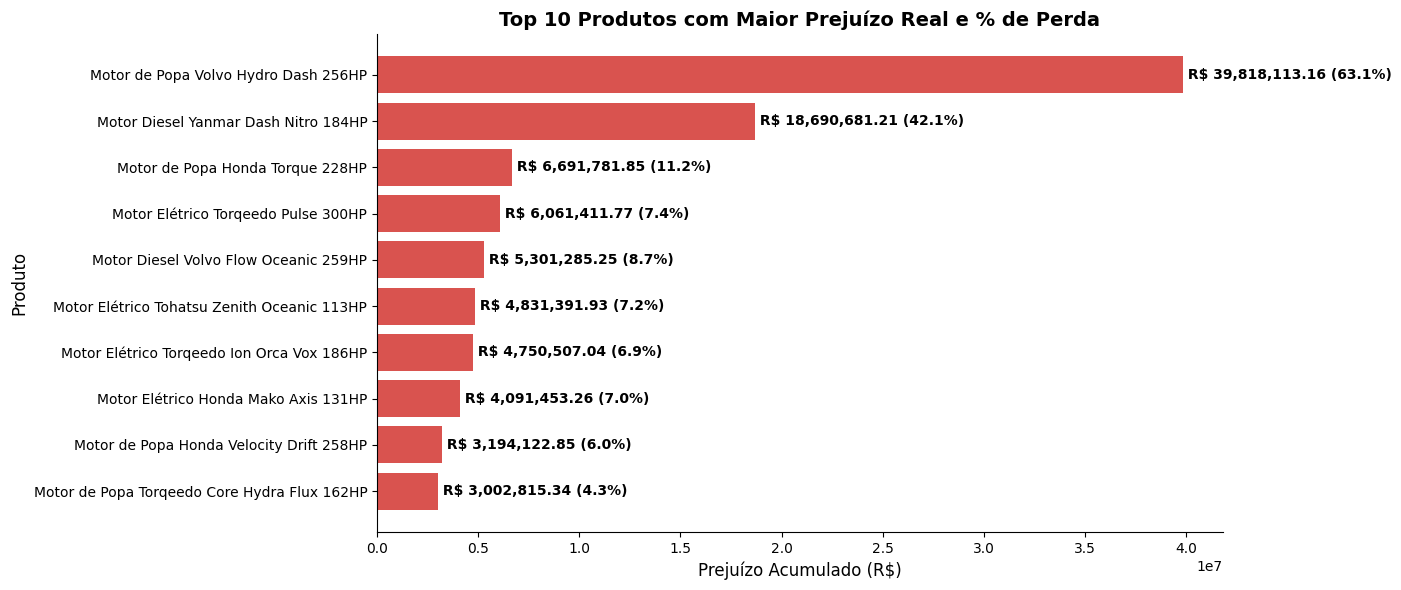

In [ ]:
# ==========================================
# PASSO 5: GERAÇÃO DO GRÁFICO VISUAL (Com Percentuais)
# ==========================================
import matplotlib.pyplot as plt

print("Gerando o gráfico de barras dos produtos com maior prejuízo...")

# 1. Pegando o top 10
top_10_prejuizo = produtos_com_prejuizo.head(10).copy()

# 2. Ordenando do menor para o maior (exigência do matplotlib para barras horizontais)
top_10_prejuizo = top_10_prejuizo.sort_values(by='prejuizo_total_brl', ascending=True)

# Vamos resetar o index para garantir que o loop funcione perfeitamente
top_10_prejuizo = top_10_prejuizo.reset_index(drop=True)

# 3. Configurando a "tela" do gráfico (aumentei um pouquinho a largura pra caber o texto)
plt.figure(figsize=(14, 6))

# 4. Criando o gráfico de barras
barras = plt.barh(top_10_prejuizo['product_name'], top_10_prejuizo['prejuizo_total_brl'], color='#d9534f')

# 5. O Toque de Mestre Turbinado: Valor em R$ + Percentual de Perda
for index, row in top_10_prejuizo.iterrows():
    valor_brl = row['prejuizo_total_brl']
    # Transforma o decimal (ex: 0.15) em porcentagem real (15.0%)
    percentual = row['percentual_perda'] * 100

    # Monta a string bonitona: R$ 1,500.00 (15.2%)
    texto_label = f' R$ {valor_brl:,.2f} ({percentual:.1f}%)'

    plt.text(valor_brl, index, texto_label, va='center', fontsize=10, fontweight='bold', color='black')

# 6. Perfumaria: Títulos e eixos limpos
plt.title('Top 10 Produtos com Maior Prejuízo Real e % de Perda', fontsize=14, fontweight='bold')
plt.xlabel('Prejuízo Acumulado (R$)', fontsize=12)
plt.ylabel('Produto', fontsize=12)

# Arrancando as bordas
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# 7. Salvando a imagem física
nome_arquivo_grafico = 'grafico_prejuizo_com_percentual.png'
plt.savefig(nome_arquivo_grafico, dpi=300)

print("--- Passo 5 Executado ---")
print(f"Gráfico '{nome_arquivo_grafico}' salvo com sucesso!")

In [ ]:
# ==========================================
# CHECKPOINT: SALVANDO A BASE DO EXERCÍCIO 4
# ==========================================
print("Salvando o checkpoint da base de vendas enriquecida...")

# Exporta a tabela com todas as datas e cotações arrumadas para um CSV físico
vendas_enriquecidas.to_csv('vendas_tratadas_ex4.csv', index=False)

print("Tabela exportada com sucesso para 'vendas_tratadas_ex4.csv'!")

Salvando o checkpoint da base de vendas enriquecida...
Tabela exportada com sucesso para 'vendas_tratadas_ex4.csv'!


# Questão 5 - Análise de clientes

Cenário

A Diretoria da LH Nautical deseja identificar os clientes fieis. Diferente de quem compra muito uma única vez, o cliente fiel é o cliente que possui um gasto médio alto por transação e navega por diversas categorias da loja. O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.

Premissas obrigatórias:

    Faturamento Total: Soma da coluna total por cliente.
    Frequência: Contagem total de transações (IDs de venda) por cliente.
    Ticket Médio: Faturamento Total / Frequência.
    Diversidade de Categorias: Quantidade de categorias distintas que o cliente comprou.
    Nota: É necessário limpar os nomes das categorias no arquivo produtos_raw.csv (ex: consolidar "Ancorajen", "Encoragem" e "Ancoragem" como uma única categoria).
    Filtro de Elite: Apenas clientes que compraram produtos de 3 ou mais categorias distintas devem ser considerados no ranking.
    Desempate: Em caso de empate no Ticket Médio, utilize o id_cliente em ordem crescente.


Tarefa:

    Realize a limpeza das categorias de produtos para evitar duplicidade por erro de grafia.
    Calcule o Ticket Médio e a Diversidade de Categorias para cada id_cliente.
    Filtre os 10 clientes com o maior Ticket Médio que atendam ao critério de diversidade (3+ categorias).
    Para este grupo específico de 10 clientes, identifique qual categoria de produto concentra a maior quantidade total de itens comprados (sum(qtd))

Antes de sair criando regras de limpeza no escuro ou fazendo substituições manuais infinitas, precisamos ver o tamanho do estrago. O objetivo deste bloco é extrair todos os valores únicos que foram digitados na coluna actual_category.

Fazer esse "raio-x" da base nos permite mapear todas as variações e erros de digitação reais. Com essa lista em mãos, conseguimos definir com precisão quais são as nossas categorias oficiais e, a partir daí, criar uma regra inteligente para automatizar a padronização, sem precisar ficar adivinhando o que o usuário pode ter digitado errado.

In [ ]:
import pandas as pd

print("Inspecionando as categorias brutas da base...")
produtos = pd.read_csv('produtos_raw.csv')

produtos['categoria_bruta'] = produtos['actual_category'].str.upper().str.strip()

lista_categorias = produtos['categoria_bruta'].dropna().unique()

print("--- Categorias Únicas Encontradas ---")
for cat in sorted(lista_categorias):
    print(f"- {cat}")

Inspecionando as categorias brutas da base...
--- Categorias Únicas Encontradas ---
- A N C O R A G E M
- ANCORAGEM
- ANCORAGEN
- ANCORAGUEM
- ANCORAJEM
- ANCORAJEN
- ANCORAJM
- E L E T R Ô N I C O S
- ELETRONICOS
- ELETRONICOZ
- ELETRONISCOS
- ELETRUNICOS
- ELETRÔNICOS
- ENCORAGEM
- ENCORAGI
- P R O P U L S Ã O
- PROP
- PROPULSAM
- PROPULSAO
- PROPULSSÃO
- PROPULSÃO
- PROPULÇAO
- PROPULÇÃO
- PROPUÇÃO


In [ ]:
import pandas as pd
import unicodedata
import difflib

# Desliga o limite de linhas do Pandas
pd.set_option('display.max_rows', None)

# Carrega os produtos
produtos = pd.read_csv('produtos_raw.csv')

# Categorias oficiais
categorias_oficiais = ['ANCORAGEM', 'ELETRONICOS', 'PROPULSAO']

def limpar_e_padronizar_categoria(texto):
    if pd.isna(texto):
        return 'DESCONHECIDO'

    texto = str(texto).upper().replace(" ", "")
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

    match = difflib.get_close_matches(texto, categorias_oficiais, n=1, cutoff=0.5)

    if match:
        return match[0]

    return texto

produtos['categoria_limpa'] = produtos['actual_category'].apply(limpar_e_padronizar_categoria)

prova_real = produtos[['code', 'name', 'actual_category', 'categoria_limpa']].sort_values('code')

print("--- LISTA COMPLETA DOS 150 PRODUTOS ---")
print(prova_real)

# Liga o limite de volta pra não poluir os próximos códigos
pd.reset_option('display.max_rows')

--- LISTA COMPLETA DOS 150 PRODUTOS ---
     code                                               name  \
0       1                        Transponder AIS Maré Magnum   
1       2                          Transponder Furuno Marlin   
2       3                       Radar Furuno Pulse Leviathan   
3       4                          Rádio AIS Hydro Tidal Zen   
4       5                     Piloto Automático Furuno Storm   
5       6                             Transponder AIS Vector   
6       7                                      Radar AIS Zen   
7       8                                        GPS AIS Zen   
8       9                        Transponder AIS Titan Pulse   
9      10         Piloto Automático Simrad Titan Flux Magnum   
10     11                GPS Furuno Swift Leviathan Poseidon   
11     12                             GPS AIS Drift Flux Vox   
12     13                                 Radar Simrad Boost   
13     14                             Rádio Furuno Zen Swift   


In [ ]:
# ==========================================
# PASSO 2: MONTANDO A FICHA DOS CLIENTES
# ==========================================
import pandas as pd

print("Iniciando o Passo 2: Construindo a ficha de cada cliente...")

# 1. Puxando o checkpoint das vendas
vendas_ex4 = pd.read_csv('vendas_tratadas_ex4.csv')

# 2. Juntando as vendas com as categorias limpas (que estão na memória do Passo 1)
vendas_com_categorias = pd.merge(
    vendas_ex4,
    produtos[['code', 'categoria_limpa']],
    left_on='id_product',
    right_on='code',
    how='left'
)

# 3. Esmagando a tabela por cliente para fazer a matemática
clientes_agrupados = vendas_com_categorias.groupby('id_client').agg(
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'nunique'), # Conta pedidos únicos
    diversidade_categorias=('categoria_limpa', 'nunique') # Conta categorias únicas
).reset_index()

# 4. Calculando a última peça: Ticket Médio
clientes_agrupados['ticket_medio'] = clientes_agrupados['faturamento_total'] / clientes_agrupados['frequencia']

# Filtro de Elite: Apenas clientes que compraram das 3 categorias
clientes_elite = clientes_agrupados[clientes_agrupados['diversidade_categorias'] >= 3]
clientes_elite.to_csv('clientes_ex5.csv', index=False)

print("--- Passo 2 Executado ---")
print("Fichas montadas com sucesso! Olha como ficou a tabela:")
print(clientes_agrupados.head(10))

Iniciando o Passo 2: Construindo a ficha de cada cliente...
--- Passo 2 Executado ---
Fichas montadas com sucesso! Olha como ficou a tabela:
   id_client  faturamento_total  frequencia  diversidade_categorias  \
0          1        51669494.40         190                       3   
1          2        67717055.25         220                       3   
2          3        60878498.10         207                       3   
3          4        59332571.15         207                       3   
4          5        61071262.70         202                       3   
5          6        54639577.40         201                       3   
6          7        50288430.85         207                       3   
7          8        55682732.20         208                       3   
8          9        72697344.85         218                       3   
9         10        52052241.60         203                       3   

    ticket_medio  
0  271944.707368  
1  307804.796591  
2  294099.024638  
3

In [ ]:
# ==========================================
# QUESTÃO 5.1: O SQL
# ==========================================
import sqlite3
import pandas as pd

print("Subindo os dados pro SQL...")

# 1. Conecta no banco virtual
conn = sqlite3.connect(':memory:')

# 2. Sobe o SEU arquivo exato (já filtrado com diversidade >= 3)
clientes_ex5 = pd.read_csv('clientes_ex5.csv')
clientes_ex5.to_sql('elite_tb', conn, index=False)

# 3. Sobe a tabela detalhada de vendas (pra podermos somar os produtos no final)
vendas_com_categorias.to_sql('vendas_tb', conn, index=False)

print("\n--- PARTE 1 E 2: OS 10 CLIENTES FIÉIS (TOP 10) ---")

# QUERY 1: Como o filtro já foi feito no Pandas, é só ordenar e pegar os 10!
query_top_10 = """
SELECT
    id_client,
    ticket_medio,
    diversidade_categorias
FROM elite_tb
ORDER BY ticket_medio DESC, id_client ASC
LIMIT 10;
"""
tabela_top10 = pd.read_sql_query(query_top_10, conn)
print(tabela_top10)


print("\n--- PARTE 3: A CATEGORIA CAMPEÃ DESSA ELITE ---")

# QUERY 2: Pega os 10 da tabela de elite e cruza com os carrinhos deles
query_campea = """
WITH Top10 AS (
    SELECT id_client
    FROM elite_tb
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
)
SELECT
    v.categoria_limpa AS categoria_campea,
    SUM(v.qtd) AS quantidade_total_itens
FROM vendas_tb v
INNER JOIN Top10 t ON v.id_client = t.id_client
GROUP BY v.categoria_limpa
ORDER BY quantidade_total_itens DESC
LIMIT 1;
"""
tabela_campea = pd.read_sql_query(query_campea, conn)
print(tabela_campea)

Subindo os dados pro SQL...

--- PARTE 1 E 2: OS 10 CLIENTES FIÉIS (TOP 10) ---
   id_client   ticket_medio  diversidade_categorias
0         47  356149.121316                       3
1          9  333474.058945                       3
2         42  333431.650225                       3
3         36  322557.828837                       3
4         28  321662.249265                       3
5         46  318072.905276                       3
6         26  312925.353052                       3
7         48  312708.661737                       3
8          2  307804.796591                       3
9         32  304164.798087                       3

--- PARTE 3: A CATEGORIA CAMPEÃ DESSA ELITE ---
  categoria_campea  quantidade_total_itens
0        PROPULSAO                    6528


Como bônus, desenvolvei a mesma solução rodando tudo diretamente no SQL, sem depender do processamento anterior no Pandas. Nessa abordagem, o próprio banco de dados calcula o ticket médio e a diversidade de categorias por cliente, aplica o filtro dos 3+ categorias, ranqueia o top 10 e ainda encontra a categoria mais consumida por esse grupo — tudo em uma única execução encadeada via CTEs. Isso seria útil em cenários onde a base é grande demais para carregar na memória, delegando o peso do processamento direto pro motor do banco.

In [ ]:
# ==========================================
# PASSO 2 E 3 (VIA SQL)
# ==========================================
import sqlite3
import pandas as pd

print("Subindo o banco virtual e resolvendo o ranking da Elite em SQL...")

# 1. Conexão na memória RAM
conn = sqlite3.connect(':memory:')

# 2. Jogando a nossa base cruzada pro SQL (Ela já deve estar viva do seu Passo 2)
vendas_com_categorias.to_sql('vendas_tb', conn, index=False)

# 3. QUERY 1: Montando a ficha e já filtrando o TOP 10 de Elite com CTEs
query_elite = """
WITH FichaClientes AS (
    SELECT
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(DISTINCT id) AS frequencia,
        COUNT(DISTINCT categoria_limpa) AS diversidade_categorias,
        (SUM(total) / COUNT(DISTINCT id)) AS ticket_medio
    FROM vendas_tb
    GROUP BY id_client
)
SELECT
    id_client,
    faturamento_total,
    frequencia,
    diversidade_categorias,
    ticket_medio
FROM FichaClientes
WHERE diversidade_categorias >= 3 -- A famosa regra das "todas as categorias"
ORDER BY ticket_medio DESC, id_client ASC
LIMIT 10;
"""

# O Pandas executa a query e já devolve a tabela bonitinha
top_10_elite = pd.read_sql_query(query_elite, conn)
print("--- TOP 10 CLIENTES DE ELITE ---")
print(top_10_elite)


# 4. QUERY 2: Descobrindo o que essa galera mais consome (A Categoria Campeã)
query_campea = """
WITH ClientesElite AS (
    -- Recriando o filtro dos 10 milionários rapidamente
    SELECT id_client
    FROM (
        SELECT id_client, (SUM(total) / COUNT(DISTINCT id)) AS ticket_medio
        FROM vendas_tb
        GROUP BY id_client
        HAVING COUNT(DISTINCT categoria_limpa) >= 3
        ORDER BY ticket_medio DESC, id_client ASC
        LIMIT 10
    )
)
SELECT
    v.categoria_limpa,
    SUM(v.qtd) AS quantidade_total
FROM vendas_tb v
INNER JOIN ClientesElite e ON v.id_client = e.id_client
GROUP BY v.categoria_limpa
ORDER BY quantidade_total DESC
LIMIT 1;
"""

campea_df = pd.read_sql_query(query_campea, conn)

print("\n--- RESULTADO FINAL DA QUESTÃO 5 ---")
print(f"🔥 A CATEGORIA FAVORITA DA ELITE É: '{campea_df['categoria_limpa'].iloc[0]}' com {campea_df['quantidade_total'].iloc[0]} itens comprados! 🔥")

Subindo o banco virtual e resolvendo o ranking da Elite em SQL...
--- TOP 10 CLIENTES DE ELITE ---
   id_client  faturamento_total  frequencia  diversidade_categorias  \
0         47        67668333.05         190                       3   
1          9        72697344.85         218                       3   
2         42        74021826.35         222                       3   
3         36        69349933.20         215                       3   
4         28        65619098.85         204                       3   
5         46        63296508.15         199                       3   
6         26        66653100.20         213                       3   
7         48        66606944.95         213                       3   
8          2        67717055.25         220                       3   
9         32        55662158.05         183                       3   

    ticket_medio  
0  356149.121316  
1  333474.058945  
2  333431.650225  
3  322557.828837  
4  321662.249265  
5  31

# Questão 6 - Dimensão de calendário

```
-- Questão 6: Dimensão de Calendário
-- Dialeto: PostgreSQL
-- Base: vendas_tratadas_ex4.csv (datas já padronizadas na Questão 4)
-- Executado no Supabase

WITH calendario AS (
    -- Gera todos os dias do período, sem pular nenhum
    SELECT generate_series(
        (SELECT MIN(sale_date::date) FROM vendas_nautical),
        (SELECT MAX(sale_date::date) FROM vendas_nautical),
        '1 day'::interval
    )::date AS data
),

vendas_diarias AS (
    -- LEFT JOIN garante que dias sem venda entram com 0, não são ignorados
    SELECT
        c.data,
        COALESCE(SUM(v.total), 0) AS total_vendas
    FROM calendario c
    LEFT JOIN vendas_nautical v ON v.sale_date::date = c.data
    GROUP BY c.data
)

SELECT
    CASE EXTRACT(DOW FROM data)
        WHEN 0 THEN 'Domingo'
        WHEN 1 THEN 'Segunda-feira'
        WHEN 2 THEN 'Terça-feira'
        WHEN 3 THEN 'Quarta-feira'
        WHEN 4 THEN 'Quinta-feira'
        WHEN 5 THEN 'Sexta-feira'
        WHEN 6 THEN 'Sábado'
    END AS dia_semana,
    ROUND(AVG(total_vendas)::numeric, 2) AS media_vendas,
    COUNT(data) AS total_dias_considerados
FROM vendas_diarias
GROUP BY EXTRACT(DOW FROM data)
ORDER BY media_vendas ASC
```

# Questão 7 - Previsão de demanda

A questão pede pra construir um modelo que tente prever quantas unidades de um produto vão ser vendidas em cada dia de janeiro de 2024, usando apenas o histórico de vendas de 2023 como base.
O modelo pedido é o mais simples que existe: pega os últimos 7 dias de vendas antes da data que você quer prever e tira a média. Essa média vira a previsão daquele dia. Depois você compara o que o modelo previu com o que realmente aconteceu em janeiro usando o MAE, que é basicamente a média dos erros absolutos dia a dia.
O MAE de 2 por exemplo significa que em média o modelo errou 2 unidades por dia. Quanto menor melhor.
A restrição mais importante é que o modelo só pode olhar para o passado. Se você tá prevendo o dia 15 de janeiro, só pode usar dados até o dia 14. Usar o dia 15 ou depois seria data leakage, que é basicamente trapacear o modelo com informação que não existiria na vida real no momento da previsão.

O primeiro passo foi isolar o produto e entender o que tínhamos.

In [ ]:
produtos[produtos['name'].str.contains('Yamaha', case=False)]

,name,price,code,actual_category,categoria_limpa
54,Motor de Popa Yamaha Evo Dash 155HP,R$ 121534.82,54,Propulssão,PROPULSAO
67,Motor Elétrico Yamaha Swift Drift Current 265HP,R$ 111505.55,64,pRoPuLsÃo,PROPULSAO
70,Motor de Popa Yamaha Mako 108HP,R$ 85789.05,67,Propulssão,PROPULSAO
92,Motor Elétrico Yamaha Orca Storm Zenith 11HP,R$ 78678.05,89,Propulssão,PROPULSAO
93,Motor de Popa Yamaha Thrust Marlin Nexus 182HP,R$ 79097.33,90,PROPULSAO,PROPULSAO
95,Motor Elétrico Yamaha Nautic Kraken 133HP,R$ 88854.1,92,Propução,PROPULSAO
96,Motor Elétrico Yamaha Flow 204HP,R$ 100477.01,93,propulsão,PROPULSAO


In [ ]:
motor = vendas[vendas['id_product'] == 54].copy()

print(f"Total de vendas do produto: {len(motor)}")
print(f"Vendas em 2023: {len(motor[motor['sale_date'].dt.year == 2023])}")
print(f"Vendas em janeiro 2024: {len(motor[(motor['sale_date'].dt.year == 2024) & (motor['sale_date'].dt.month == 1)])}")

Total de vendas do produto: 62
Vendas em 2023: 29
Vendas em janeiro 2024: 2


28 dias com venda em 2023, 337 sem. Reconstruí o calendário completo forçando zeros nos dias sem venda, porque ignorá-los distorceria qualquer cálculo de média.

In [ ]:
treino = motor[motor['sale_date'] <= '2023-12-31'].groupby('sale_date')['qtd'].sum()
calendario_treino = pd.date_range('2023-01-01', '2023-12-31')
treino = treino.reindex(calendario_treino, fill_value=0)

Com a série pronta, apliquei a média móvel garantindo que cada previsão usasse apenas os 7 dias anteriores à data prevista.

In [ ]:
import numpy as np

teste = motor[
    (motor['sale_date'] >= '2024-01-01') &
    (motor['sale_date'] <= '2024-01-31')
].groupby('sale_date')['qtd'].sum()

calendario_teste = pd.date_range('2024-01-01', '2024-01-31')
teste = teste.reindex(calendario_teste, fill_value=0)

In [ ]:
serie_completa = pd.concat([treino, teste])

previsoes = []
for data in calendario_teste:
    janela = serie_completa[serie_completa.index < data].tail(7)
    previsoes.append(janela.mean())

mae = np.mean(np.abs(np.array(previsoes) - teste.values))
print(f"MAE: {mae:.4f}")

MAE: 0.9954


O MAE de 0.9954 parece razoável, mas esconde o problema real: nos dois únicos dias com venda em janeiro o modelo previu 0 e 1.57, quando o real foi 11 e 6. O baseline não é adequado para produtos com demanda esparsa, a média móvel fica anestesiada pelos zeros e não captura os picos que são exatamente o que importa para a gestão de estoque.

In [ ]:
previsoes_df = pd.DataFrame({
    'previsto': previsoes
}, index=calendario_teste)

primeira_semana = previsoes_df['2024-01-01':'2024-01-07']
print(round(primeira_semana['previsto'].sum()))

0


# Questão 8 - Sistema de recomendação

In [ ]:
# ==========================================
# QUESTÃO 8: SISTEMA DE RECOMENDAÇÃO
# ==========================================
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

print("Lendo os dados...")

# 1. Puxando as nossas tabelas
vendas = pd.read_csv('vendas_tratadas_ex4.csv')
produtos = pd.read_csv('produtos_raw.csv')

# O nome exato do produto que a Marina quer analisar
nome_gps = 'GPS Garmin Vortex Maré Drift'

# Pegando o código (ID) desse GPS na tabela de produtos
id_gps = produtos[produtos['name'] == nome_gps]['code'].values[0]

print("Montando a Matriz de Clientes x Produtos...")

# --- PASSO 1 DO ENUNCIADO: Criar a Matriz com 1 e 0 ---
# Vamos criar uma coluna dizendo '1' pra toda venda (significa presença)
vendas['presenca'] = 1

# Transformando a tabela normal numa "Planilha Gigante" (Pivot Table)
# Linhas = Clientes | Colunas = Produtos | Valores = 1 ou 0
matriz = vendas.pivot_table(
    index='id_client',
    columns='id_product',
    values='presenca',
    fill_value=0 # Preenche com zero quem não comprou
)

# Como o cliente pode ter comprado o mesmo produto 3 vezes e a tabela ia somar dando '3',
# a gente força tudo que for maior que 0 a virar 1 (Presença/Ausência apenas, como o enunciado pediu)
matriz = matriz.clip(upper=1)


print("Calculando quem anda junto com quem...")

# --- PASSO 2 DO ENUNCIADO: Similaridade de Cosseno ---
# O '.T' vira a matriz de lado para comparar Produto com Produto (e não Cliente com Cliente)
# A função cosine_similarity faz a matemática chata de comparar as colunas
calculo_similaridade = cosine_similarity(matriz.T)

# Transformando o resultado num formato de tabela fácil de ler
tabela_similaridade = pd.DataFrame(
    calculo_similaridade,
    index=matriz.columns,
    columns=matriz.columns
)


print("Gerando o Top 5 da Marina...")

# --- PASSO 3 DO ENUNCIADO: O Ranking do GPS ---
# Pega só a nota de similaridade do nosso GPS com todos os outros produtos
ranking_gps = tabela_similaridade[id_gps]

# Tira o próprio GPS da lista (ele tem similaridade máxima com ele mesmo, óbvio)
ranking_gps = ranking_gps.drop(id_gps)

# Ordena do maior pro menor e pega os 5 primeiros
top_5_ids = ranking_gps.sort_values(ascending=False).head(5).reset_index()

# Renomeando as colunas pra cruzar com os nomes reais
top_5_ids.columns = ['code', 'score_similaridade']

# Cruzando com a tabela de produtos para pegar o Nome do produto (e não só o número)
resultado_final = pd.merge(top_5_ids, produtos[['code', 'name']], on='code', how='left')

print(f"\n✅ VITRINE: QUEM COMPROU O '{nome_gps}', TAMBÉM LEVOU:")
for posicao, linha in resultado_final.iterrows():
    print(f"{posicao + 1}º -> {linha['name']} (Score: {linha['score_similaridade']:.4f})")

print("O id_produto campeão é:", resultado_final.iloc[0]['code'])

Lendo os dados...
Montando a Matriz de Clientes x Produtos...
Calculando quem anda junto com quem...
Gerando o Top 5 da Marina...

✅ VITRINE: QUEM COMPROU O 'GPS Garmin Vortex Maré Drift', TAMBÉM LEVOU:
1º -> Motor de Popa Volvo Magnum 276HP (Score: 0.8696)
2º -> GPS Furuno Swift Leviathan Poseidon (Score: 0.8680)
3º -> Radar Furuno Swift (Score: 0.8539)
4º -> Transponder AIS Maré Magnum (Score: 0.8500)
5º -> Cabo de Nylon Delta Force Magnum Leviathan (Score: 0.8500)
O id_produto campeão é: 94
